In [93]:
import numpy as np

def signmoid(z):
    return 1/(1 + np.exp(-z))

In [94]:
def compute_loss(y, p):
    eps = 1e-15

    p = np.clip(p, eps, 1-eps)

    return {
        -np.mean(y*np.log(p) + (1-y)* np.log(1-p))
    }

In [178]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer

class LogisticRegression:
    def __init__(self):
        self.w =  np.array([0.0])
        self.b = 0
        self.epochs = 500
        self.lr = 0.1
    
    def fit(self, X, y):
        epochs = 500
        lr = 0.1
        m = len(y)
        
        for epoch in range(self.epochs):

            z = X @ self.w + self.b
        
            p = signmoid(z)
            loss = compute_loss(y, p)
        
            dw = (1/m) * (X.T @ (p-y))
        
            db = (1/m) * np.sum(p-y)
        
            self.w -= self.lr * dw
            self.b -= self.lr * db
            
            if epoch % 100 == 0:
                print(
                    f"Epoch {epoch}, Loss {loss} "
                    
                )
            

    def predict_proba(self, X):
        z = X @ self.w + self.b
        p = signmoid(z)
        
        return p

    def predict(self, X):
        p = self.predict_proba(X)

        return (p >= 0.5).astype(int)

    def visualize(self):
        x_plot = np.linspace(0, 10, 100)

        y_plot = signmoid(self.w * x_plot + b)
        
        plt.scatter(X, y)
        plt.plot(x_plot, y_plot)
        plt.show()
        

Epoch 0, Loss {np.float64(0.6931471805599453)} 
Epoch 100, Loss {np.float64(0.4308971647598818)} 
Epoch 200, Loss {np.float64(0.3313381183058879)} 
Epoch 300, Loss {np.float64(0.2736825460671165)} 
Epoch 400, Loss {np.float64(0.23613190362783285)} 


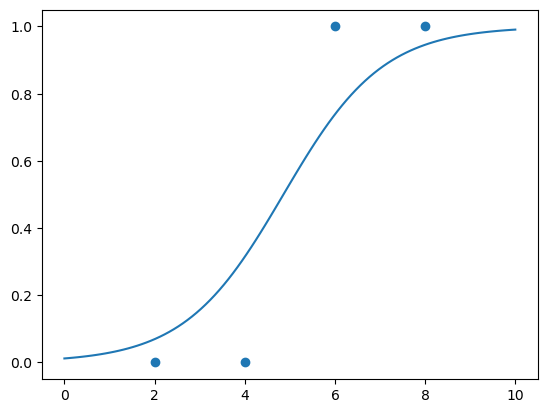

In [179]:
model = LogisticRegression()
model.fit(X, y)
model.predict([[7]])
model.visualize()

In [184]:
data = load_breast_cancer()
data.target[[10, 50, 85]]
data.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [185]:
print(data.data[0])
print(data.target[0])

[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
 1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
 6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
 1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
 4.601e-01 1.189e-01]
0


In [ ]:
X = data.data
y = data.target